<a href="https://colab.research.google.com/github/QasimNiazi86/GAN/blob/main/Tutorial16Tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:00<00:00, 43.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.15MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.51MB/s]


Epoch [1/20] D Loss: 0.0006 G Loss: 8.0481
Epoch [2/20] D Loss: 0.0002 G Loss: 9.2354
Epoch [3/20] D Loss: 0.0001 G Loss: 9.9150
Epoch [4/20] D Loss: 0.1360 G Loss: 4.7065
Epoch [5/20] D Loss: 0.0023 G Loss: 6.9772


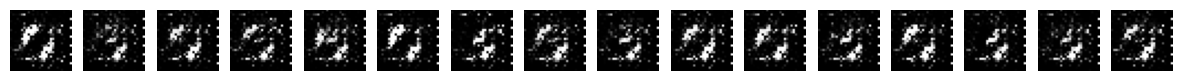

Epoch [6/20] D Loss: 0.0014 G Loss: 7.3196
Epoch [7/20] D Loss: 0.0007 G Loss: 8.4083
Epoch [8/20] D Loss: 0.0005 G Loss: 8.8748
Epoch [9/20] D Loss: 0.0001 G Loss: 9.6681
Epoch [10/20] D Loss: 0.0001 G Loss: 9.5458


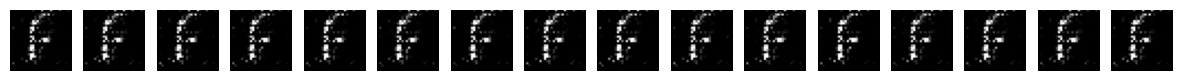

Epoch [11/20] D Loss: 0.0001 G Loss: 10.0222
Epoch [12/20] D Loss: 0.7897 G Loss: 1.5275
Epoch [13/20] D Loss: 0.9622 G Loss: 1.0809
Epoch [14/20] D Loss: 0.8213 G Loss: 1.5750
Epoch [15/20] D Loss: 0.9027 G Loss: 1.0413


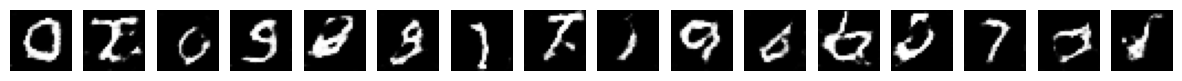

Epoch [16/20] D Loss: 0.9109 G Loss: 0.8368
Epoch [17/20] D Loss: 0.8316 G Loss: 1.3123
Epoch [18/20] D Loss: 1.1731 G Loss: 2.0287
Epoch [19/20] D Loss: 0.7085 G Loss: 1.3760
Epoch [20/20] D Loss: 0.8324 G Loss: 1.2092


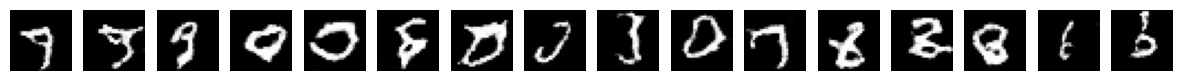

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ==========================================
# Task 3: Augmented Images
# ==========================================
# Added data augmentation (RandomRotation and RandomAffine) to the pipeline
transform = transforms.Compose([
    transforms.RandomRotation(15),           # Augmentation: Rotate by up to 15 degrees
    transforms.RandomAffine(0, translate=(0.1, 0.1)), # Augmentation: Translate by 10%
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))     # Normalize to range [-1, 1]
])

# Task 1: Changed Hyperparameters
batch_size = 128 # Changed from 64
latent_dim = 100
epochs = 20      # Changed from 50
lr = 0.0002
beta1 = 0.5      # Recommended momentum parameter for DCGANs

# Load dataset
train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================================
# Task 2: Convolutional Layers (DCGAN)
# ==========================================

class ConvGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(ConvGenerator, self).__init__()
        self.model = nn.Sequential(
            # Input is latent vector Z, going into a convolution
            nn.ConvTranspose2d(latent_dim, 256, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # State size: 256 x 7 x 7
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # State size: 128 x 14 x 14
            nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
            # Output state size: 1 x 28 x 28
        )

    def forward(self, z):
        # Reshape latent vector into a 1x1 spatial grid
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.model(z)

class ConvDiscriminator(nn.Module):
    def __init__(self):
        super(ConvDiscriminator, self).__init__()
        self.model = nn.Sequential(
            # Input size: 1 x 28 x 28
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # State size: 64 x 14 x 14
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # State size: 128 x 7 x 7
            nn.Conv2d(128, 1, kernel_size=7, stride=1, padding=0, bias=False),
            nn.Sigmoid()
            # Output state size: 1 x 1 x 1
        )

    def forward(self, x):
        return self.model(x).view(-1, 1) # Flatten to batch_size x 1

# Initialize models
generator = ConvGenerator(latent_dim).to(device)
discriminator = ConvDiscriminator().to(device)

# Loss and optimizers (Using Binary Cross-Entropy as in the tutorial)
criterion = nn.BCELoss()
generator_optimizer = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
discriminator_optimizer = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

# ==========================================
# Training Loop
# ==========================================

def train_dcgan(generator, discriminator, train_loader, epochs, latent_dim):
    for epoch in range(epochs):
        for i, (real_images, _) in enumerate(train_loader):
            current_batch_size = real_images.size(0)
            real_images = real_images.to(device)

            # Labels
            real_labels = torch.ones(current_batch_size, 1).to(device)
            fake_labels = torch.zeros(current_batch_size, 1).to(device)

            # ---------------------
            # 1. Train Discriminator
            # ---------------------
            discriminator_optimizer.zero_grad()

            # Real loss
            real_outputs = discriminator(real_images)
            real_loss = criterion(real_outputs, real_labels)

            # Fake loss
            noise = torch.randn(current_batch_size, latent_dim).to(device)
            fake_images = generator(noise)
            fake_outputs = discriminator(fake_images.detach())
            fake_loss = criterion(fake_outputs, fake_labels)

            # Total D loss
            d_loss = real_loss + fake_loss
            d_loss.backward()
            discriminator_optimizer.step()

            # ---------------------
            # 2. Train Generator
            # ---------------------
            generator_optimizer.zero_grad()

            # Generate fake images and calculate loss
            fake_outputs = discriminator(fake_images)
            # Generator wants discriminator to output 1 (real) for fake images
            g_loss = criterion(fake_outputs, real_labels)

            g_loss.backward()
            generator_optimizer.step()

        # Print losses at the end of the epoch
        print(f"Epoch [{epoch+1}/{epochs}] D Loss: {d_loss.item():.4f} G Loss: {g_loss.item():.4f}")

        # Visualize generated images every 5 epochs
        if (epoch + 1) % 5 == 0:
            generate_images(generator, latent_dim)

def generate_images(generator, latent_dim, num_images=16):
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(num_images, latent_dim).to(device)
        generated_images = generator(noise).detach().cpu()

    # Plot images
    fig, axes = plt.subplots(1, num_images, figsize=(15, 2))
    for i in range(num_images):
        axes[i].imshow(generated_images[i].squeeze(), cmap="gray")
        axes[i].axis("off")
    plt.show()
    generator.train()

# Run the training
train_dcgan(generator, discriminator, train_loader, epochs, latent_dim)